# Doo — Logistic Regression 베이스라인

Online Retail II 고객 이탈 예측을 위한 로지스틱 회귀 베이스라인입니다.

- Train 데이터로만 모델을 학습합니다.
- Validation 데이터로 성능과 분류 임계값을 비교합니다.
- Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.
- 팀 공통 시드 `random_state=42`를 사용합니다.

In [1]:
from pathlib import Path
import pickle

import pandas as pd

# 프로젝트 루트 또는 models 폴더에서 실행해도 경로가 동작하도록 처리
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "models":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 데이터 확인

피처, 자료형, 결측치를 확인합니다.

In [2]:
display(X_train.head())
display(pd.DataFrame({
    "dtype": X_train.dtypes,
    "train_missing": X_train.isna().sum(),
    "val_missing": X_val.isna().sum(),
}))
display(y_train.value_counts().rename_axis("churn").to_frame("count"))

,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.671757,1.614952,-0.407252,-0.671793,-0.406069,0.616805,0.0,1.0,1.0,0.0
1,-0.965400,-0.314654,-0.475206,-0.745705,-1.605762,-0.078723,0.0,1.0,0.0,0.0
2,-1.073778,0.274474,-0.475206,-0.736466,-1.245854,0.695333,0.0,1.0,0.0,0.0
3,-0.542093,-1.091619,-0.475206,-0.440820,-2.080423,-1.099580,0.0,1.0,0.0,1.0
4,-0.942516,0.641611,-0.407252,-0.487015,-0.473878,0.543887,1.0,1.0,0.0,0.0


,dtype,train_missing,val_missing
net_revenue,float64,0,0
recency_days,float64,0,0
frequency,float64,0,0
distinct_products,float64,0,0
tenure_days,float64,0,0
avg_days_between_orders,float64,0,0
is_low_value,float64,0,0
is_uk,float64,0,0
has_return,float64,0,0
recent_activity_ratio,float64,0,0


,count
churn,
0,1312
1,1280


## 2. 모델 학습

전처리된 Train 데이터로 로지스틱 회귀를 학습합니다.

In [3]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

logistic_model.fit(X_train, y_train)
print("학습 완료")

학습 완료


## 3. Validation 기본 성능

기본 분류 임계값 0.5에서 성능을 확인합니다. Recall을 우선해서 비교합니다.

In [4]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

logistic_val_pred = logistic_model.predict(X_val)
logistic_val_proba = logistic_model.predict_proba(X_val)[:, 1]

logistic_metrics_05 = pd.Series({
    "accuracy": accuracy_score(y_val, logistic_val_pred),
    "recall": recall_score(y_val, logistic_val_pred),
    "precision": precision_score(y_val, logistic_val_pred),
    "f1": f1_score(y_val, logistic_val_pred),
    "roc_auc": roc_auc_score(y_val, logistic_val_proba),
}, name="threshold_0.50")

display(logistic_metrics_05.to_frame())
print("Confusion matrix")
print(confusion_matrix(y_val, logistic_val_pred))
print("\nClassification report")
print(classification_report(y_val, logistic_val_pred, digits=3))

,threshold_0.50
accuracy,0.697917
recall,0.669789
precision,0.704433
f1,0.686675
roc_auc,0.758300


Confusion matrix
[[317 120]
 [141 286]]

Classification report
              precision    recall  f1-score   support

           0      0.692     0.725     0.708       437
           1      0.704     0.670     0.687       427

    accuracy                          0.698       864
   macro avg      0.698     0.698     0.698       864
weighted avg      0.698     0.698     0.698       864



## 4. 임계값 비교

Validation 데이터에서 Recall과 Precision의 균형을 비교합니다. Test 데이터로 임계값을 정하면 안 됩니다.

In [5]:
logistic_threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    logistic_threshold_pred = (logistic_val_proba >= threshold).astype(int)
    logistic_threshold_results.append({
        "threshold": threshold,
        "recall": recall_score(y_val, logistic_threshold_pred),
        "precision": precision_score(y_val, logistic_threshold_pred, zero_division=0),
        "f1": f1_score(y_val, logistic_threshold_pred, zero_division=0),
        "predicted_churn_count": int(logistic_threshold_pred.sum()),
    })

logistic_threshold_df = pd.DataFrame(logistic_threshold_results)
display(logistic_threshold_df.style.format({
    "threshold": "{:.2f}",
    "recall": "{:.3f}",
    "precision": "{:.3f}",
    "f1": "{:.3f}",
}))

,threshold,recall,precision,f1,predicted_churn_count
0,0.30,0.920,0.589,0.718,667
1,0.35,0.864,0.614,0.718,601
2,0.40,0.810,0.642,0.716,539
3,0.45,0.742,0.667,0.703,475
4,0.50,0.670,0.704,0.687,406
5,0.55,0.604,0.731,0.662,353
6,0.60,0.525,0.747,0.616,300
7,0.65,0.461,0.758,0.574,260
8,0.70,0.356,0.772,0.487,197


## 5. 피처 계수 확인

양수 계수는 이탈 확률 증가 방향, 음수 계수는 감소 방향을 뜻합니다. 전처리 컬럼 순서가 정확히 매핑되었는지 확인한 뒤 해석해야 합니다.

In [6]:
logistic_coefficient_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": logistic_model.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

display(logistic_coefficient_df)

,feature,coefficient,abs_coefficient
0,net_revenue,-0.510156,0.510156
9,recent_activity_ratio,-0.378081,0.378081
2,frequency,-0.372132,0.372132
3,distinct_products,-0.302224,0.302224
1,recency_days,0.300775,0.300775
5,avg_days_between_orders,0.188413,0.188413
7,is_uk,-0.125630,0.125630
4,tenure_days,0.102367,0.102367
6,is_low_value,-0.042638,0.042638
8,has_return,0.022688,0.022688


## 6. 혼동행렬 시각화

기본 임계값 0.5에서 실제값과 예측값을 히트맵으로 확인합니다.

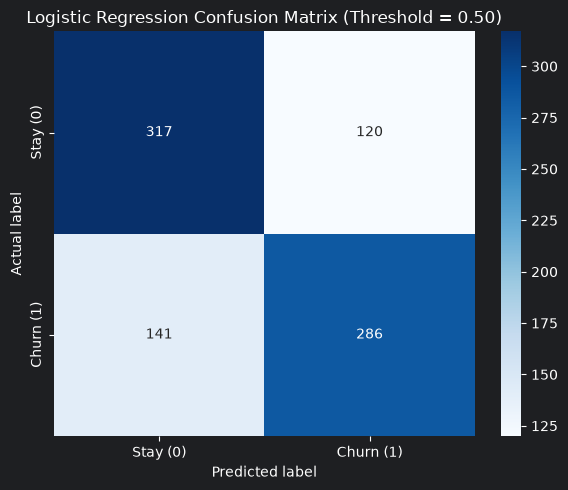

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

logistic_confusion_matrix = confusion_matrix(y_val, logistic_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"],
)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Logistic Regression Confusion Matrix (Threshold = 0.50)")
plt.tight_layout()
plt.show()

## 7. 임계값별 성능 변화

임계값이 변할 때 Recall, Precision, F1-score가 어떻게 달라지는지 비교합니다.

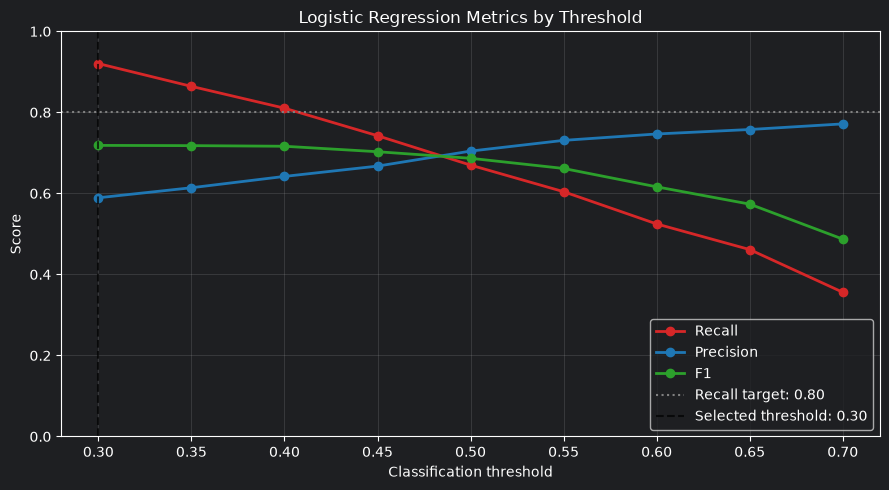

In [8]:
plt.figure(figsize=(9, 5))

for metric, color in [("recall", "tab:red"), ("precision", "tab:blue"), ("f1", "tab:green")]:
    plt.plot(
        logistic_threshold_df["threshold"],
        logistic_threshold_df[metric],
        marker="o",
        linewidth=2,
        color=color,
        label=metric.upper() if metric == "f1" else metric.title(),
    )

plt.axhline(0.80, color="gray", linestyle=":", label="Recall target: 0.80")
plt.axvline(0.30, color="black", linestyle="--", alpha=0.7, label="Selected threshold: 0.30")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Logistic Regression Metrics by Threshold")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 8. ROC Curve와 Precision–Recall Curve

ROC Curve는 전체적인 분류 능력을, Precision–Recall Curve는 이탈 고객 탐지 성능의 균형을 보여줍니다.

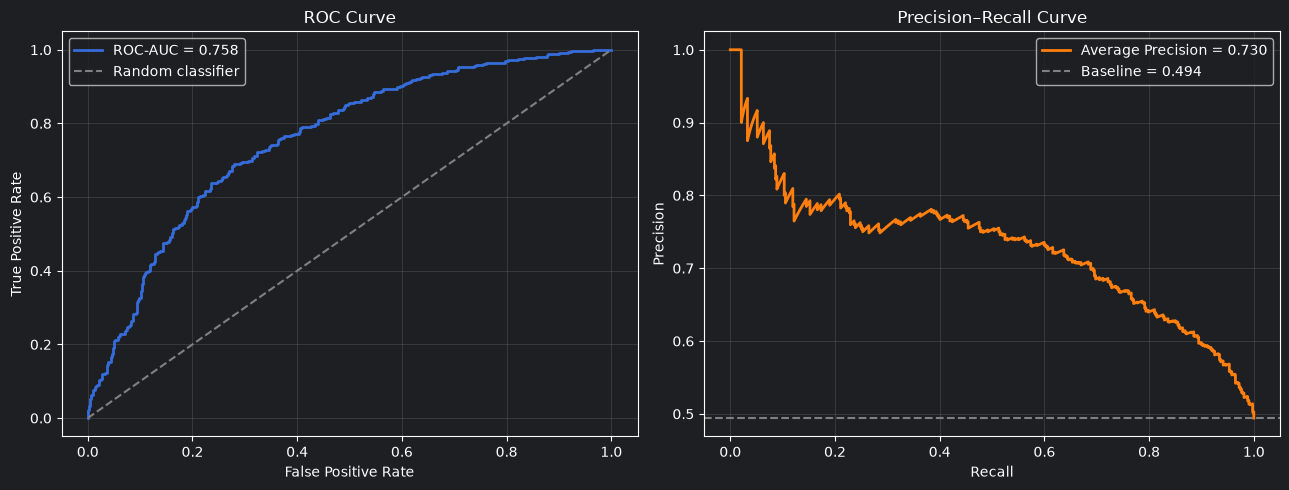

In [9]:
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

logistic_fpr, logistic_tpr, _ = roc_curve(y_val, logistic_val_proba)
logistic_roc_auc = auc(logistic_fpr, logistic_tpr)

logistic_pr_precision, logistic_pr_recall, _ = precision_recall_curve(
    y_val, logistic_val_proba
)
logistic_average_precision = average_precision_score(y_val, logistic_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    logistic_fpr,
    logistic_tpr,
    linewidth=2,
    label=f"ROC-AUC = {logistic_roc_auc:.3f}",
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    logistic_pr_recall,
    logistic_pr_precision,
    linewidth=2,
    color="tab:orange",
    label=f"Average Precision = {logistic_average_precision:.3f}",
)
axes[1].axhline(y_val.mean(), linestyle="--", color="gray", label=f"Baseline = {y_val.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 9. 실험 결과 기록

아래 셀에 선택한 임계값과 선택 이유를 기록하세요. 최종 모델로 확정되기 전에는 Test 데이터를 평가하지 않습니다.

In [10]:
# 예시: Recall이 0.80 이상인 후보 중 F1이 가장 높은 임계값 확인
logistic_candidates = logistic_threshold_df[logistic_threshold_df["recall"] >= 0.80]
if logistic_candidates.empty:
    print("Recall 0.80 이상인 임계값 후보가 없습니다.")
else:
    logistic_best_candidate = logistic_candidates.loc[logistic_candidates["f1"].idxmax()]
    display(logistic_best_candidate.to_frame("selected_value"))

,selected_value
threshold,0.300000
recall,0.920375
precision,0.589205
f1,0.718464
predicted_churn_count,667.000000


## 10. 모델 구성 및 평가 기준 설명

이 노트북은 수업에서 배운 `LogisticRegression`의 기본 흐름인 **데이터 준비 → 모델 학습 → 예측 → 평가 → 회귀계수 확인**을 고객 이탈 예측 문제에 맞게 확장했다.

### 데이터 사용 원칙

- 팀장이 동일한 기준으로 생성한 `X_train`, `y_train`, `X_val`, `y_val`을 사용해 팀원 간 모델 비교 조건을 통일했다.
- 전처리기는 Train 데이터로만 학습되어 있으므로 데이터 누수를 방지한다.
- Test 데이터는 최종 모델을 결정한 뒤 한 번만 평가하기 위해 이 노트북에서 불러오지 않았다.

### Logistic Regression을 사용한 이유

- 빠르고 안정적인 이진 분류 모델이므로 다른 모델과 비교하기 위한 베이스라인으로 적합하다.
- `predict_proba()`로 고객별 이탈 확률을 얻을 수 있다.
- 회귀계수의 부호와 크기를 통해 각 피처가 이탈 확률에 미치는 방향을 비교적 쉽게 설명할 수 있다.
- `max_iter=1000`은 충분한 수렴을 위한 반복 횟수 상한이고, `random_state=42`는 팀 공통 재현성 기준이다.

### Recall과 임계값을 함께 확인한 이유

실제 이탈 고객을 잔류 고객으로 놓치는 경우가 중요하므로 Recall을 우선한다. 기본 임계값 0.5만 사용하지 않고 0.30~0.70을 비교하여 Recall, Precision, F1-score의 변화를 확인했다. 임계값을 낮추면 더 많은 이탈 고객을 찾을 수 있지만 잔류 고객에게도 불필요한 캠페인을 제공할 수 있으므로 Precision과 예측 대상 수도 함께 기록했다.

### 평가 및 시각화 목적

- 혼동행렬: 실제 이탈 고객을 놓친 수와 잔류 고객을 잘못 선별한 수를 확인한다.
- ROC-AUC: 특정 임계값과 무관한 전반적인 분류 능력을 비교한다.
- Precision–Recall Curve: Recall과 Precision의 균형을 확인한다.
- 회귀계수: 피처별 영향 방향을 해석한다. 단, 계수는 인과관계를 뜻하지 않으며 상관이 높은 피처가 있으면 해석에 주의한다.

최종 모델은 동일한 Validation 데이터와 평가 규칙으로 Random Forest 등 다른 후보 모델과 비교한 뒤 선정한다.